# Mobility CIR/PDP Export + Path Check

필요한 기능만 유지:
- 경로 시각화 확인
- Interactive 차량 이동 위젯
- 프레임별 CIR/PDP 이미지 저장


In [52]:
# import 전에 GPU 제한
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "1"

import gc
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import drjit as dr
import mitsuba as mi
from IPython.display import display

import sionna.rt
from sionna.rt import load_scene

import importlib
import utils as ut
ut = importlib.reload(ut)

print('TensorFlow:', tf.__version__)
print('CUDA_VISIBLE_DEVICES =', os.environ.get('CUDA_VISIBLE_DEVICES'))


TensorFlow: 2.19.0
CUDA_VISIBLE_DEVICES = 1


In [ ]:
# -------------------------
# Config
# -------------------------
XML_PATH = "/home/js/js/sionna-rt/src/sionna/rt/scenes/HSV/HSV_flat.xml"
ROAD_OBJECT_ID = "elm__19"

TX_POSITIONS = [[0, -264, 11]]
TX_NAMES = ["Tx_1"]
TX_POWER_DBM = 43.0

PATH_INDICES = [4, 16]
Z_OFFSET = 2.7
SPEED_MS = 100.0 / 3.6
TARGET_FRAMES = 281

# export
EXPORT_DIR = Path("cir_pdp_exports/")
BANDWIDTH = 500e6
L_MIN, L_MAX = 0, 4094
SAMPLING_FREQUENCY = 1e5
NUM_TIME_STEPS = 1

# -------------------------------------------------
# Solver profile
# -------------------------------------------------
SIM_PROFILE = 'balanced'   # 'safe' | 'balanced' | 'high'

if SIM_PROFILE == 'safe':
    MAX_DEPTH = 2
    SAMPLES_PER_SRC = 20000
    DIFFUSE_REFLECTION = False
    DIFFRACTION = False
elif SIM_PROFILE == 'balanced':
    MAX_DEPTH = 3
    SAMPLES_PER_SRC = 50000
    DIFFUSE_REFLECTION = True
    DIFFRACTION = False
elif SIM_PROFILE == 'high':
    MAX_DEPTH = 4
    SAMPLES_PER_SRC = 100000
    DIFFUSE_REFLECTION = True
    DIFFRACTION = True
else:
    raise ValueError(f"Unknown SIM_PROFILE: {SIM_PROFILE}")

SYNTHETIC_ARRAY = True

BATCH_SIZE = 10
FIGSIZE = (10, 6)
DPI = 130
CHIP_NS = 2.0

# 전력 표기 방식
NORMALIZE_TO_PEAK = True
DB_OFFSET = 0.0

# 측정-like 노이즈 바닥(시각화용)
ADD_MEASUREMENT_NOISE = True
NOISE_FLOOR_REL_DB = -45.0
NOISE_RANDOM_SEED = 1234

# CIR 계산 방식
USE_CIR_API = True


[탐색] Mitsuba Scene 내부에서 'elm__19' 형상을 찾습니다...
  -> 추출된 도로 좌표 수: 24개 (dtype=float32)
total_distance(m)= 403.058
total_time(s)= 14.51
delta_t(s)= 0.037591
frames= 387


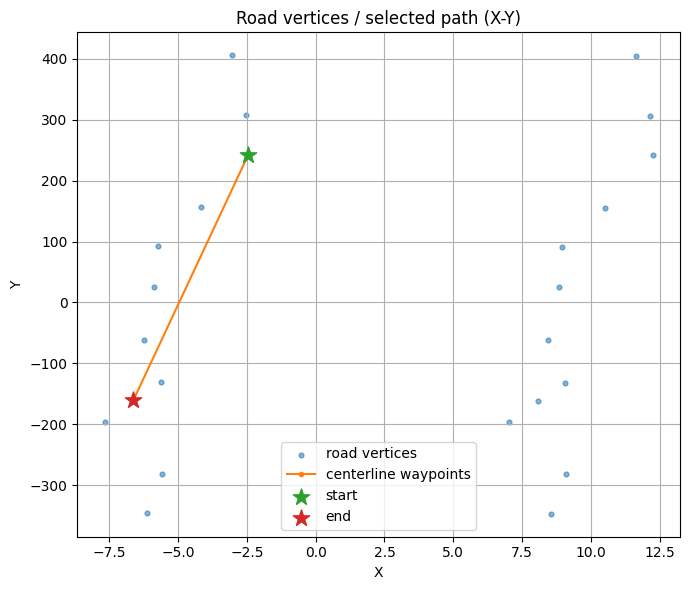

In [54]:
# -------------------------
# Scene + Path setup
# -------------------------
scene = load_scene(XML_PATH, merge_shapes=False)
scene.frequency = 28e9

road_positions = ut.get_road_positions_from_object(
    scene,
    ROAD_OBJECT_ID,
    dtype=np.float32,
    round_decimals=3,
)
if len(road_positions) == 0:
    raise RuntimeError('road_positions is empty')

_tmp = ut.prepare_vehicle_path(
    road_positions=road_positions,
    path_indices=PATH_INDICES,
    z_offset=Z_OFFSET,
    speed_ms=SPEED_MS,
    delta_t=0.5,
)
delta_t = float(_tmp['total_time']) / float(TARGET_FRAMES - 1)

path_data = ut.prepare_vehicle_path(
    road_positions=road_positions,
    path_indices=PATH_INDICES,
    z_offset=Z_OFFSET,
    speed_ms=SPEED_MS,
    delta_t=delta_t,
)

print('total_distance(m)=', round(path_data['total_distance'], 3))
print('total_time(s)=', round(path_data['total_time'], 3))
print('delta_t(s)=', round(delta_t, 6))
print('frames=', len(path_data['time_steps']))

# 경로 시각화(필수 요청)
ut.plot_vertices_xy(
    road_positions,
    waypoints=path_data['waypoints'],
    start_point=PATH_INDICES[0],
    end_point=PATH_INDICES[-1],
    figsize=(7, 6),
)


In [55]:
# -------------------------
# Tx/Rx setup + Interactive widget
# -------------------------
tx_names, rx, solver, vehicle = ut.setup_scene_for_vehicle_path(
    scene=scene,
    path_data=path_data,
    tx_positions=TX_POSITIONS,
    tx_names=TX_NAMES,
    tx_power_dbm=TX_POWER_DBM,
    display_radius=2.0,
    add_vehicle=True,
    vehicle_name="rx_vehicle",
    vehicle_scale=(2.5, 2.5, 2.5),
    vehicle_z=1.3,
    rx_z=4.0,
)

slider, output_widget = ut.create_vehicle_simulation_widgets(
    scene=scene,
    path_data=path_data,
    tx_names=tx_names,
    rx=rx,
    solver=solver,
    vehicle=vehicle,
    vehicle_z=1.3,
    rx_z=4.0,
    max_depth=3,
    max_num_paths_per_src=100000,
    samples_per_src=100000,
    diffuse_reflection=True,
    diffraction=True,
    synthetic_array=True,
    resolution=(800, 600),
)
print("▼ 슬라이더를 움직여보세요.")
display(slider, output_widget)


▼ 슬라이더를 움직여보세요.


IntSlider(value=0, description='Time Step:', layout=Layout(width='600px'), max=386)

Output()

In [56]:
# -------------------------
# CIR/PDP export helpers
# -------------------------
def _apply_db_mode(cir_db, pdp_db):
    if NORMALIZE_TO_PEAK:
        peak = max(np.max(cir_db), np.max(pdp_db))
        cir_db = cir_db - peak
        pdp_db = pdp_db - peak
    if DB_OFFSET != 0.0:
        cir_db = cir_db + DB_OFFSET
        pdp_db = pdp_db + DB_OFFSET
    return cir_db, pdp_db


def _inject_noise_on_cir(h_cir, frame_idx):
    """B 방식: 복소 CIR(h)에만 노이즈 추가하고 PDP는 |h|^2로 계산."""
    if not ADD_MEASUREMENT_NOISE:
        return h_cir

    rng = np.random.default_rng(NOISE_RANDOM_SEED + int(frame_idx))

    peak_p = float(np.max(np.abs(h_cir)**2)) if np.size(h_cir) else 0.0
    if peak_p <= 0:
        return h_cir

    noise_p = peak_p * (10.0 ** (NOISE_FLOOR_REL_DB / 10.0))

    sigma = np.sqrt(max(noise_p, 1e-30) / 2.0)
    n_re = rng.normal(0.0, sigma, size=h_cir.shape)
    n_im = rng.normal(0.0, sigma, size=h_cir.shape)
    return h_cir + (n_re + 1j*n_im)


def _extract_1d_paths_from_cir(a, tau):
    """paths.cir() 출력에서 단일 링크의 path 계수/지연 1D 추출."""
    a_np = a.numpy() if hasattr(a, "numpy") else np.asarray(a)
    tau_np = tau.numpy() if hasattr(tau, "numpy") else np.asarray(tau)

    a_np = np.squeeze(a_np)
    tau_np = np.squeeze(tau_np)

    while tau_np.ndim > 1:
        tau_np = tau_np[0]

    while a_np.ndim > 2:
        a_np = a_np[0]

    p = tau_np.shape[0]
    if a_np.ndim == 1:
        if a_np.shape[0] != p:
            raise ValueError(f"a/tau path size mismatch: a={a_np.shape}, tau={tau_np.shape}")
        a_path = a_np
    elif a_np.ndim == 2:
        if a_np.shape[0] == p:
            a_path = a_np[:, 0]
        elif a_np.shape[1] == p:
            a_path = a_np[0, :]
        else:
            raise ValueError(f"cannot align a with tau: a={a_np.shape}, tau={tau_np.shape}")
    else:
        raise ValueError(f"unexpected a shape after squeeze: {a_np.shape}")

    return a_path.astype(np.complex128), tau_np.astype(np.float64)


def _cir_pdp_from_paths_cir(paths):
    """Sionna paths.cir()를 4095 chip bin으로 매핑."""
    a, tau = paths.cir(out_type="tf", normalize_delays=False)
    a_path, tau_s = _extract_1d_paths_from_cir(a, tau)

    n_bins = int(L_MAX - L_MIN + 1)
    dt = 1.0 / float(BANDWIDTH)  # 2 ns @ 500 MHz

    # delay(초) -> chip index
    k = np.rint(tau_s / dt).astype(np.int64)
    idx = k - int(L_MIN)
    valid = (idx >= 0) & (idx < n_bins)

    h_bin = np.zeros(n_bins, dtype=np.complex128)
    pdp_bin = np.zeros(n_bins, dtype=np.float64)

    # CIR: coherent sum, PDP: incoherent power sum
    np.add.at(h_bin, idx[valid], a_path[valid])
    np.add.at(pdp_bin, idx[valid], np.abs(a_path[valid]) ** 2)

    return h_bin, pdp_bin


def _cir_pdp_from_paths_taps(paths, tx_idx=0):
    """fallback: taps 기반."""
    h = paths.taps(
        bandwidth=float(BANDWIDTH),
        l_min=int(L_MIN),
        l_max=int(L_MAX),
        sampling_frequency=float(SAMPLING_FREQUENCY),
        num_time_steps=int(NUM_TIME_STEPS),
        normalize=False,
        normalize_delays=False,
        out_type="tf",
    )
    h_sel = h[0, :, int(tx_idx), :, 0, :]
    h_cir = tf.reduce_sum(h_sel, axis=[0, 1]).numpy()
    pdp = tf.reduce_sum(tf.abs(h_sel) ** 2, axis=[0, 1]).numpy()
    return h_cir, pdp


def save_cir_pdp_plot(cir_db, pdp_db, frame_idx, t_s, out_png):
    x_chips = np.arange(L_MIN, L_MAX + 1)

    fig, axes = plt.subplots(2, 1, figsize=FIGSIZE, sharex=True)

    axes[0].plot(x_chips, cir_db, lw=1.0)
    axes[0].set_title(f"CIR (frame={frame_idx}, t={t_s:.3f}s)")
    axes[0].set_ylabel("Power [dB]")
    axes[0].set_xlabel("Time delay [chips]")
    axes[0].set_xticks([0, 1000, 2000, 3000])
    axes[0].tick_params(axis="x", labelbottom=True)
    axes[0].grid(True, alpha=0.3)
    axes[0].text(
        1.02,
        0.5,
        f"1 chip = {CHIP_NS:g} ns\nmax 4095 chips = {4095*CHIP_NS:.0f} ns",
        transform=axes[0].transAxes,
        ha="left",
        va="center",
        fontsize=9,
    )

    axes[1].plot(x_chips, pdp_db, lw=1.0, color="tab:orange")
    axes[1].set_title("PDP = |CIR|^2")
    axes[1].set_xlabel("Time delay [chips]")
    axes[1].set_ylabel("Power [dB]")
    axes[1].set_xticks([0, 1000, 2000, 3000])
    axes[1].grid(True, alpha=0.3)
    axes[1].text(
        1.02,
        0.5,
        f"1 chip = {CHIP_NS:g} ns\nmax 4095 chips = {4095*CHIP_NS:.0f} ns",
        transform=axes[1].transAxes,
        ha="left",
        va="center",
        fontsize=9,
    )

    fig.tight_layout()
    out_png.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(out_png, dpi=DPI, bbox_inches="tight")
    plt.close(fig)


def export_one_frame(frame_idx, out_dir, tx_idx=0):
    eps = 1e-30
    t = float(path_data["time_steps"][frame_idx])
    pos, vel = ut.get_state_at_time(path_data, t)

    rx.position = pos
    rx.velocity = vel
    for name in tx_names:
        scene.transmitters[name].look_at(pos)

    paths = solver(
        scene,
        max_depth=MAX_DEPTH,
        samples_per_src=SAMPLES_PER_SRC,
        diffuse_reflection=DIFFUSE_REFLECTION,
        diffraction=DIFFRACTION,
        synthetic_array=SYNTHETIC_ARRAY,
    )

    if USE_CIR_API:
        h_cir, pdp = _cir_pdp_from_paths_cir(paths)
    else:
        h_cir, pdp = _cir_pdp_from_paths_taps(paths, tx_idx=tx_idx)

    # B 방식: CIR에만 노이즈 추가 -> PDP는 |h_noisy|^2
    h_cir_vis = _inject_noise_on_cir(h_cir, frame_idx)
    pdp_vis = np.abs(h_cir_vis) ** 2

    cir_db = 20.0 * np.log10(np.maximum(np.abs(h_cir_vis), eps))
    pdp_db = 10.0 * np.log10(np.maximum(pdp_vis, eps))

    cir_db, pdp_db = _apply_db_mode(cir_db, pdp_db)

    out_png = out_dir / f"snapshot_{frame_idx+1:04d}.png"
    save_cir_pdp_plot(cir_db, pdp_db, frame_idx, t, out_png)

    del paths, h_cir, pdp, h_cir_vis, pdp_vis, cir_db, pdp_db
    gc.collect()
    try:
        tf.keras.backend.clear_session()
    except Exception:
        pass

    return out_png


def export_batches(batch_size=BATCH_SIZE, tx_idx=0, resume=True):
    out_dir = EXPORT_DIR
    out_dir.mkdir(parents=True, exist_ok=True)
    n = len(path_data["time_steps"])
    print(f"export start: frames={n}, batch_size={batch_size}, out={out_dir.resolve()}")

    for s in range(0, n, batch_size):
        e = min(n, s + batch_size)
        print(f"\n[batch] {s}..{e-1}")
        for i in range(s, e):
            out_png = out_dir / f"snapshot_{i+1:04d}.png"
            if resume and out_png.exists():
                continue
            p = export_one_frame(i, out_dir, tx_idx=tx_idx)
            print(" saved", p.name)

    print("done")


In [57]:
print('frames =', len(path_data['time_steps']))
print('SIM_PROFILE =', SIM_PROFILE)
print('USE_CIR_API =', USE_CIR_API)
print('MAX_DEPTH =', MAX_DEPTH, '| SAMPLES_PER_SRC =', SAMPLES_PER_SRC)
print('DIFFUSE_REFLECTION =', DIFFUSE_REFLECTION, '| DIFFRACTION =', DIFFRACTION)
print('NORMALIZE_TO_PEAK =', NORMALIZE_TO_PEAK, '| DB_OFFSET =', DB_OFFSET)
print('ADD_MEASUREMENT_NOISE =', ADD_MEASUREMENT_NOISE, '| NOISE_FLOOR_REL_DB =', NOISE_FLOOR_REL_DB)

# 1) 먼저 소량 테스트
# export_batches(batch_size=5, tx_idx=0, resume=False)

# 2) 전체 실행
export_batches(batch_size=BATCH_SIZE, tx_idx=0, resume=True)

print('Noise mode = B (noise on CIR only, PDP = |h_noisy|^2)')


frames = 387
SIM_PROFILE = balanced
USE_CIR_API = True
MAX_DEPTH = 3 | SAMPLES_PER_SRC = 50000
DIFFUSE_REFLECTION = True | DIFFRACTION = False
NORMALIZE_TO_PEAK = True | DB_OFFSET = 0.0
ADD_MEASUREMENT_NOISE = True | NOISE_FLOOR_REL_DB = -45.0
export start: frames=387, batch_size=10, out=/data/js/sionna-rt/jinsup/cir_pdp_exports

[batch] 0..9
 saved snapshot_0001.png
 saved snapshot_0002.png
 saved snapshot_0003.png
 saved snapshot_0004.png
 saved snapshot_0005.png
 saved snapshot_0006.png
 saved snapshot_0007.png
 saved snapshot_0008.png
 saved snapshot_0009.png
 saved snapshot_0010.png

[batch] 10..19
 saved snapshot_0011.png
 saved snapshot_0012.png
 saved snapshot_0013.png
 saved snapshot_0014.png
 saved snapshot_0015.png
 saved snapshot_0016.png
 saved snapshot_0017.png
 saved snapshot_0018.png
 saved snapshot_0019.png
 saved snapshot_0020.png

[batch] 20..29
 saved snapshot_0021.png
 saved snapshot_0022.png
 saved snapshot_0023.png
 saved snapshot_0024.png
 saved snapshot_0025.pn

KeyboardInterrupt: 